In [28]:
import ee
import geemap

ee.Authenticate()
ee.Initialize()

# Destop GIS

In [1]:
from docx import document

In [ ]:
pip install python-dox

## Elevation Profile Extraction Along a Cross-Section Line

This section generates an elevation profile along a user-defined line using Digital Elevation Model (DEM) raster data.

### Overview

The workflow performs the following operations:

1. **Library Imports**

   * `rasterio` — for reading raster elevation data
   * `numpy` — numerical operations
   * `geopandas` — handling vector spatial data
   * `pandas` — tabular data manipulation

2. **Data Loading**

   * Reads a shapefile containing a cross-section line.
   * Loads an additional path shapefile (reference geometry).
   * Opens a DEM raster file used for elevation sampling.

3. **Coordinate Extraction**

   * Retrieves the start and end coordinates of the line segment.
   * Computes horizontal distance components between the endpoints.

4. **Point Interpolation Along Line**

   * Generates evenly spaced intermediate points between the start and end coordinates.
   * Stores the resulting coordinates in a DataFrame.
   * Converts them into a GeoDataFrame with geographic CRS (EPSG:4326).

5. **Projection to Metric CRS**

   * Reprojects points to Web Mercator (EPSG:3857) to enable distance calculations in meters.
   * Computes cumulative horizontal distance from the first point.

6. **Elevation Sampling**

   * Extracts elevation values for each point from the DEM raster.
   * Assigns sampled elevation to the GeoDataFrame.

7. **Profile Creation & Visualization**

   * Builds a profile dataset containing:

     * Horizontal distance
     * Elevation
   * Plots elevation versus distance to visualize terrain variation along the cross-section.

### Purpose

This procedure enables terrain profiling for applications such as:

* Topographic analysis
* Infrastructure planning
* Hydrological or coastal studies
* Geospatial visualization of elevation change along linear features


C:\Users\HP\AppData\Roaming\Python\Python311\site-packages\pyproj\crs\crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
C:\Users\HP\AppData\Local\Temp\ipykernel_8124\589725966.py:61: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[r

<Axes: xlabel='h_distance'>

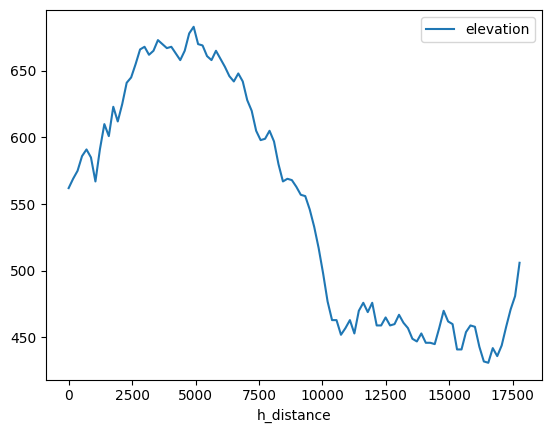

In [2]:
import rasterio
import numpy as np
import geopandas as gpd
import pandas as pd

# Read line
line = gpd.read_file(r"C:/Users/HP/Documents/Arc files/cros_profilel.shp")
cross_section_path = gpd.read_file(r"C:/Users/HP/Documents/Arc files/line_pathh.shp")
# DEM
raster_path = r"C:/Users/HP/Downloads/n00_e014_1arc_v3 (1).tif"
dem = rasterio.open(raster_path)

# Start and end coordinates
start_coord = list(line.geometry[0].coords[0])
end_coord   = list(line.geometry[0].coords[1])

# Number of intermediate points
n = 100

# Store coordinates
lon = [start_coord[0]]
lat = [start_coord[1]]

# Distances
x_dist = end_coord[0] - start_coord[0]
y_dist = end_coord[1] - start_coord[1]

# Generate points
for i in range(1, n + 1):
    x = start_coord[0] + (x_dist / (n + 1)) * i
    y = start_coord[1] + (y_dist / (n + 1)) * i

    lon.append(x)
    lat.append(y)

# Add end point
lon.append(end_coord[0])
lat.append(end_coord[1])

df = pd.DataFrame({'latitude': lat,
                    'longitude': lon})

gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude))
gdf.crs = {'init':'epsg:4326'}

gdf_pcs = gdf.to_crs(epsg=3857)

gdf_pcs['h_distance'] = 0

gdf_pcs['h_distance'] = gdf_pcs.geometry.distance(gdf_pcs.geometry.iloc[0])



# Extracting the elevation from the raster data
gdf_pcs['elevation'] = 0

for index, row in  gdf_pcs.iterrows():
    roww, col = dem.index(row['longitude'], row['latitude'])
    dem_data = dem.read(1)

    gdf_pcs['elevation'].loc[index] = dem_data[roww,col]
# print(dem.meta)
# print(gdf_pcs)

profile = gdf_pcs[['h_distance', 'elevation']]
profile.plot(x='h_distance', y='elevation')

## Create cross-section

## Automated Cross-Section Generation Perpendicular to a Path

This section generates multiple cross-section lines perpendicular to a reference path at regular intervals. These cross-sections can be used for terrain profiling, shoreline analysis, or spatial sampling along a corridor.

### Workflow Description

1. **Geometry Preparation**

   * Converts both the path geometry and the base reference line into a projected coordinate system (EPSG:3857) to ensure measurements are in meters.
   * Extracts the primary geometries from the GeoDataFrames.

2. **Cross-Section Length Definition**

   * Uses the length of the base line to define the total cross-section span.
   * Calculates half the length so cross-sections can be centered on each sampled point.

3. **Sampling Along the Path**

   * Defines a fixed interval distance (e.g., 6000 meters).
   * Generates sampling distances along the path using `numpy.arange`.
   * Interpolates points along the path at each distance.

4. **Orientation Calculation**

   * Computes local direction of the path using a small forward step.
   * Calculates the path angle using `atan2`.
   * Determines the perpendicular orientation by adding 90°.

5. **Cross-Section Construction**

   * Builds a temporary horizontal line centered at the origin.
   * Rotates it to align perpendicular to the path direction.
   * Translates the line so it is centered on the interpolated path point.
   * Stores each generated cross-section.

6. **Output Creation**

   * Combines all cross-sections into a GeoDataFrame.
   * Converts them back to geographic coordinates (EPSG:4326).
   * Prints the number of generated cross-sections.

### Purpose

This automated approach enables systematic spatial sampling along linear features for:

* Elevation or bathymetric profiling
* Shoreline change analysis
* Infrastructure corridor assessment
* Environmental monitoring

By ensuring cross-sections are perpendicular to the path, spatial measurements remain consistent and analytically reliable.


In [3]:
from shapely.geometry import LineString
from shapely.affinity import rotate

path = cross_section_path.to_crs(3857)
base_line = line.to_crs(3857)

path_geom = path.geometry.iloc[0]
base_geom = base_line.geometry.iloc[0]


section_length = base_geom.length

half_len = section_length / 2


interval = 6000

distances = np.arange(0, path_geom.length, interval)

sections = []

for d in distances:

    # Point on path
    p = path_geom.interpolate(d)

    # Small step forward to compute direction
    p2 = path_geom.interpolate(min(d + 1, path_geom.length))

    dx = p2.x - p.x
    dy = p2.y - p.y

    # Angle of path
    angle = np.degrees(np.arctan2(dy, dx))

    # Build horizontal line centered at origin
    temp_line = LineString([
        (-half_len, 0),
        (half_len, 0)
    ])

    # Rotate to perpendicular direction
    perp_line = rotate(temp_line, angle + 90, origin=(0,0))

    # Move to point location
    perp_line = LineString([
        (x + p.x, y + p.y)
        for x,y in perp_line.coords
    ])

    sections.append(perp_line)


sections_gdf = gpd.GeoDataFrame(geometry=sections, crs=3857)
sections_gdf = sections_gdf.to_crs(4326)

print("Generated", len(sections_gdf), "cross sections")


Generated 15 cross sections


## Elevation Sampling Along Generated Cross-Sections

This section extracts elevation values from the DEM along each previously generated cross-section line. The result is a collection of elevation profiles representing terrain variation across the path corridor.

### Workflow Description

1. **Profile Container Initialization**

   * Creates an empty list to store elevation profiles for each cross-section.

2. **Efficient Raster Access**

   * Reads the DEM raster band once (`dem.read(1)`) and stores it in memory.
   * This avoids repeated disk access during sampling, improving performance.

3. **Cross-Section Iteration**

   * Iterates through each cross-section geometry.
   * Ensures geometries are in geographic coordinates (EPSG:4326) compatible with raster indexing.

4. **Point Sampling Along Each Section**

   * Extracts start and end coordinates of each cross-section.
   * Generates evenly spaced points between them using `numpy.linspace`.
   * These points represent sampling locations along the section.

5. **Elevation Extraction**

   * Converts each coordinate to raster row/column indices using `dem.index()`.
   * Retrieves elevation values from the raster array.
   * Stores the elevation sequence for that section.

6. **Profile Storage**

   * Appends each section’s elevation list to `profiles`.
   * The final structure contains multiple elevation profiles corresponding to all cross-sections.

### Purpose

This process enables systematic terrain analysis across multiple transects, supporting tasks such as:

* Topographic profiling
* Coastal or riverbank cross-analysis
* Infrastructure corridor assessment
* Environmental or geomorphological studies

The extracted profiles can be used for visualization, statistical comparison, or further geospatial modeling.


In [4]:
profiles = []

band = dem.read(1)   # READ ONCE ONLY

for sec in sections_gdf.to_crs(4326).geometry:

    start, end = list(sec.coords)

    n = 100
    xs = np.linspace(start[0], end[0], n)
    ys = np.linspace(start[1], end[1], n)

    elev = []

    for x,y in zip(xs,ys):
        r,c = dem.index(x,y)
        elev.append(band[r,c])

    profiles.append(elev)


## Inspecting Extracted Elevation Profiles

This cell displays the `profiles` object, which contains elevation values sampled along each generated cross-section.

### Description

* Each element in `profiles` represents one cross-section.
* Within each element is a list of elevation values sampled at evenly spaced points along that section.
* The structure can be interpreted as:

```
profiles[section_index][point_index]
```

Where:

* `section_index` → identifies the cross-section
* `point_index` → identifies the sampling location along that cross-section

### Purpose

Viewing this output allows verification that elevation extraction was successful before proceeding to visualization or further analysis, such as:

* Plotting terrain profiles
* Statistical comparison between sections
* Identifying elevation trends or anomalies


In [5]:
profiles

[[np.int16(614),
  np.int16(615),
  np.int16(616),
  np.int16(649),
  np.int16(653),
  np.int16(636),
  np.int16(658),
  np.int16(654),
  np.int16(651),
  np.int16(640),
  np.int16(620),
  np.int16(600),
  np.int16(617),
  np.int16(633),
  np.int16(629),
  np.int16(630),
  np.int16(637),
  np.int16(624),
  np.int16(630),
  np.int16(636),
  np.int16(685),
  np.int16(688),
  np.int16(693),
  np.int16(692),
  np.int16(692),
  np.int16(689),
  np.int16(692),
  np.int16(687),
  np.int16(690),
  np.int16(697),
  np.int16(680),
  np.int16(685),
  np.int16(688),
  np.int16(689),
  np.int16(687),
  np.int16(690),
  np.int16(686),
  np.int16(680),
  np.int16(675),
  np.int16(675),
  np.int16(677),
  np.int16(677),
  np.int16(680),
  np.int16(675),
  np.int16(667),
  np.int16(657),
  np.int16(651),
  np.int16(664),
  np.int16(672),
  np.int16(665),
  np.int16(664),
  np.int16(657),
  np.int16(648),
  np.int16(634),
  np.int16(614),
  np.int16(618),
  np.int16(613),
  np.int16(612),
  np.int16(620

## plots out the profiles

## Visualization of Elevation Profiles

This section visualizes the extracted elevation profiles by plotting each cross-section’s elevation values as a line graph.

### Workflow Description

1. **Library Imports**

   * `matplotlib.pyplot` — used for plotting graphs
   * `numpy` — used to generate sample indices for the x-axis

2. **Profile Iteration**

   * Loops through each elevation profile stored in `profiles`.
   * Each profile corresponds to a single cross-section.

3. **Axis Construction**

   * Generates an x-axis representing sampling positions along the cross-section.
   * Uses sample indices rather than physical distance for simplicity.

4. **Plot Generation**

   * Creates a new figure for each profile.
   * Plots elevation against sample position.
   * Adds descriptive titles and axis labels.

5. **Display**

   * Shows each plot individually for inspection and comparison.

### Purpose

Plotting the elevation profiles allows visual assessment of terrain variation across each cross-section, helping to:

* Identify slopes, peaks, and depressions
* Compare terrain characteristics between sections
* Validate sampling results
* Support further geospatial or engineering analysis


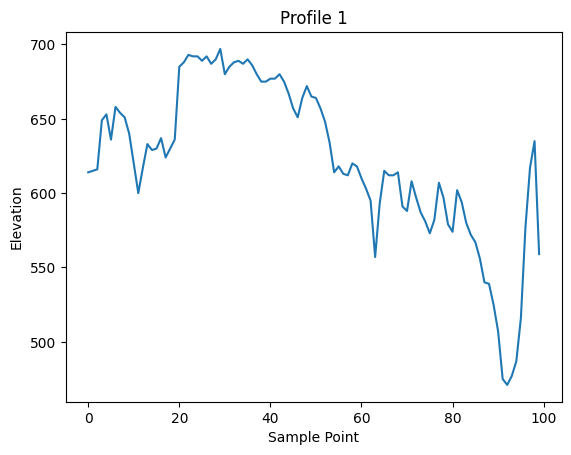

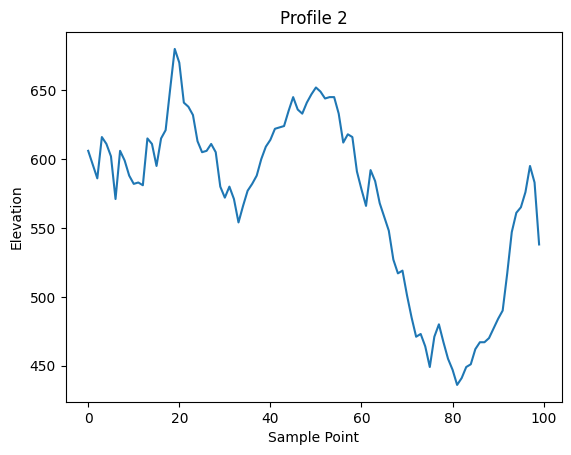

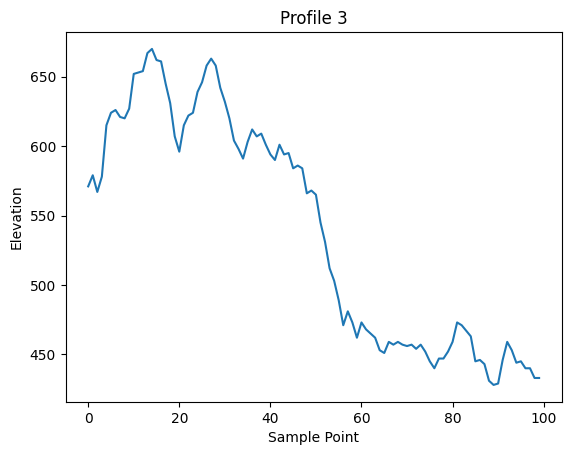

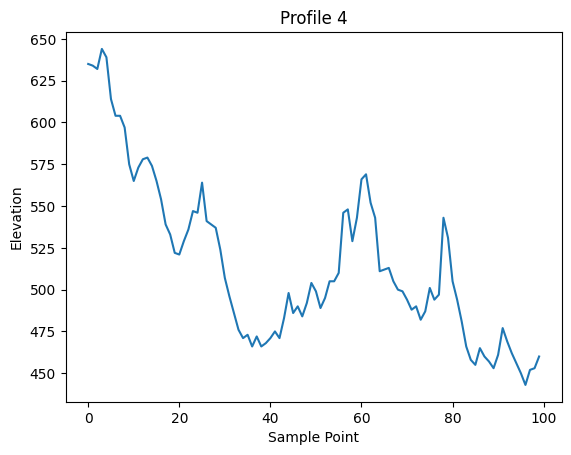

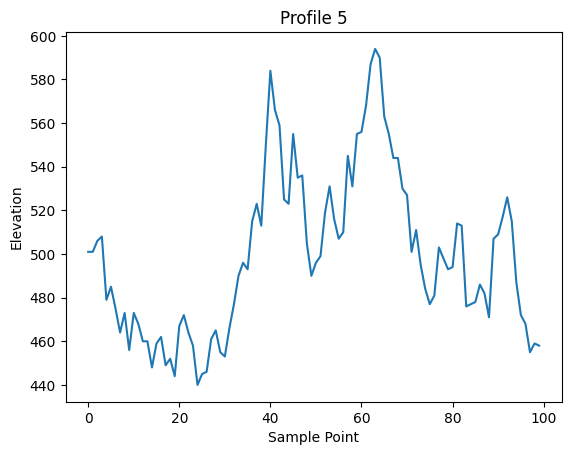

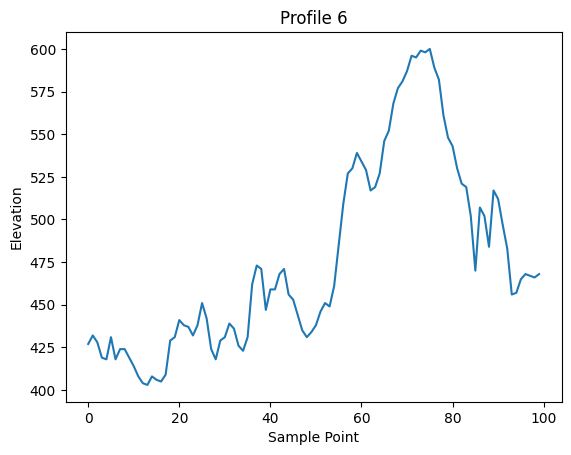

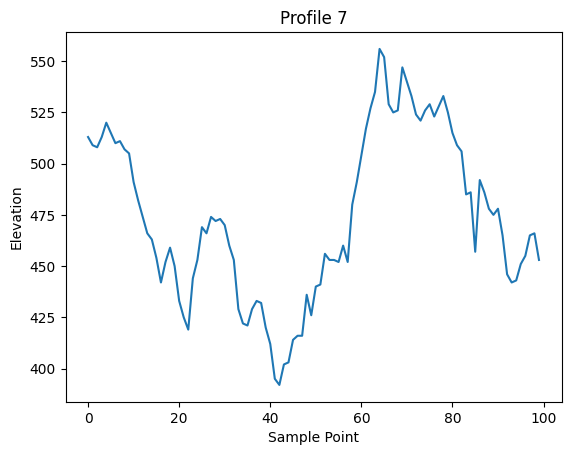

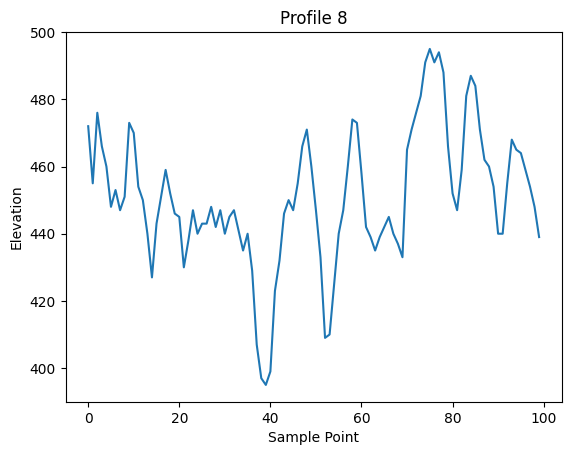

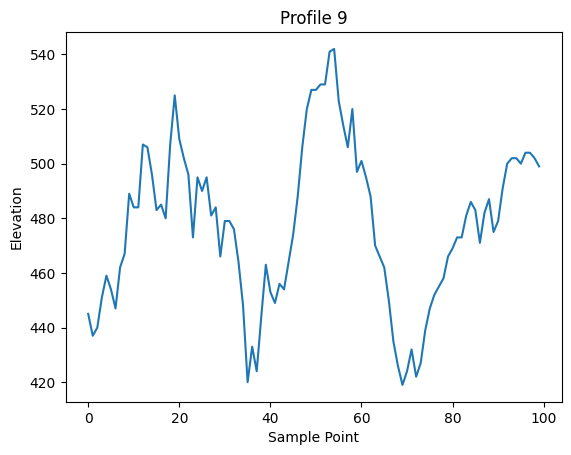

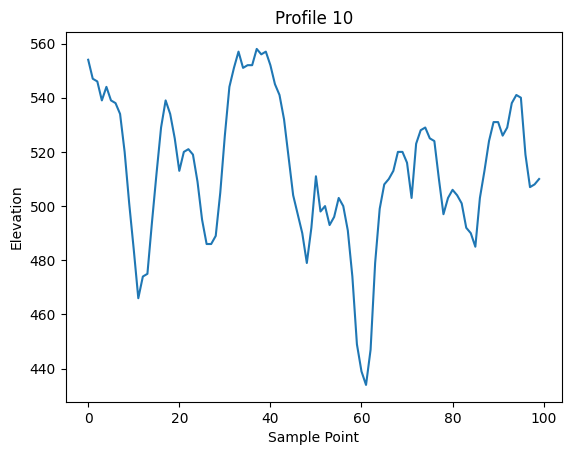

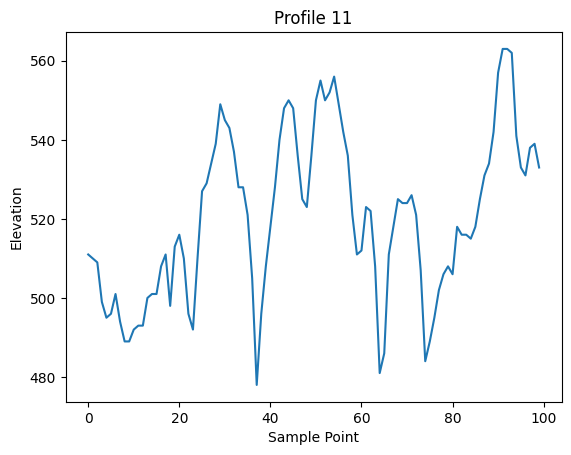

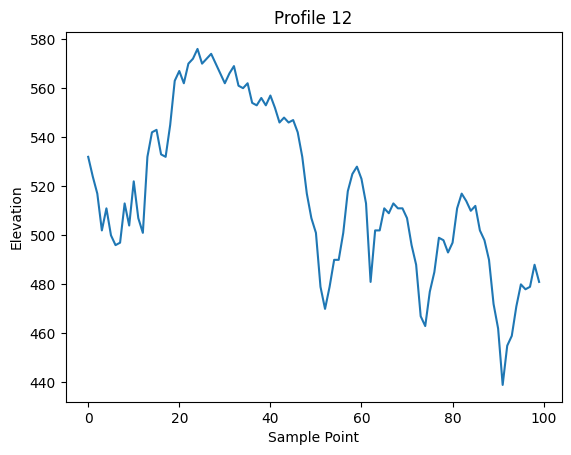

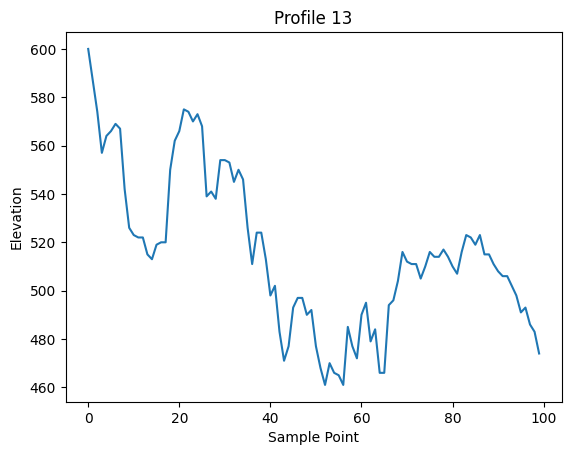

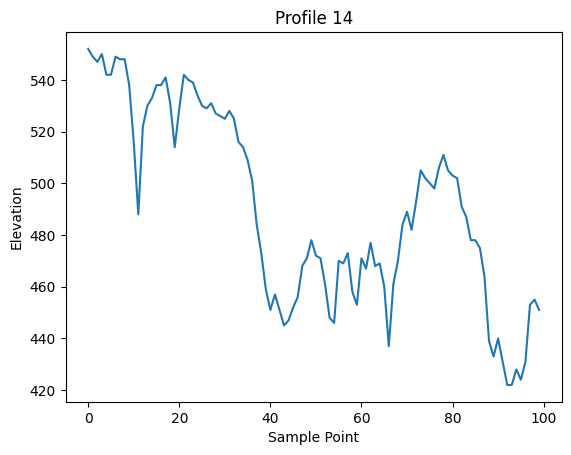

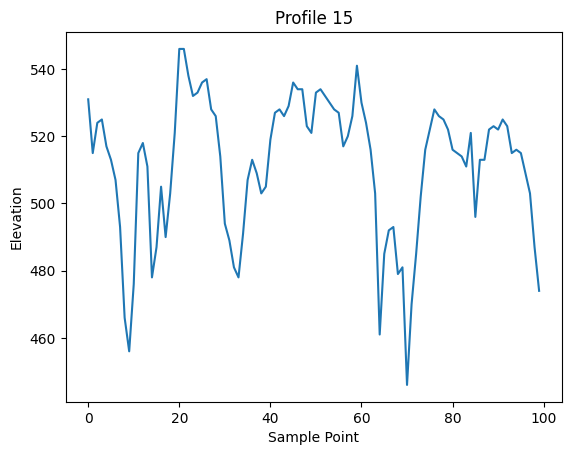

In [6]:
import matplotlib.pyplot as plt
import numpy as np

for i, profile in enumerate(profiles):

    # Create x-axis (distance/sample index)
    x = np.arange(len(profile))

    plt.figure()
    plt.plot(x, profile)

    plt.title(f"Profile {i+1}")
    plt.xlabel("Sample Point")
    plt.ylabel("Elevation")

    plt.show()


## PLot style 2

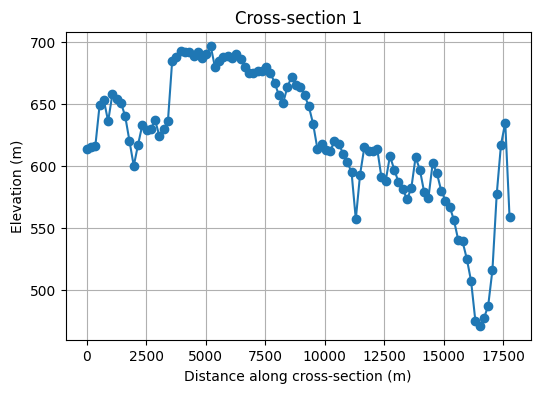

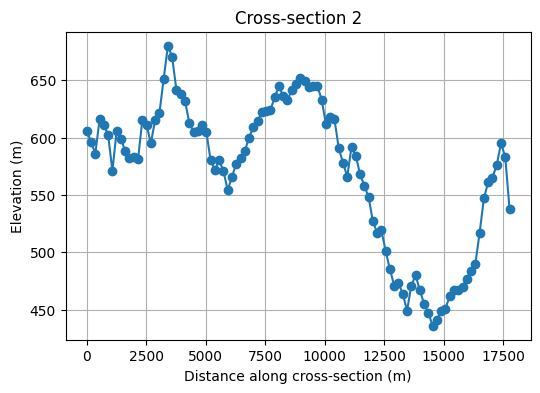

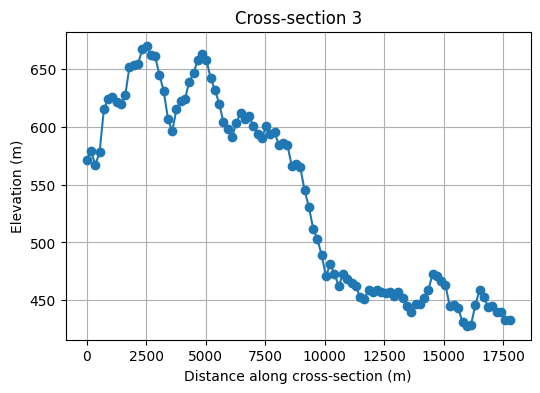

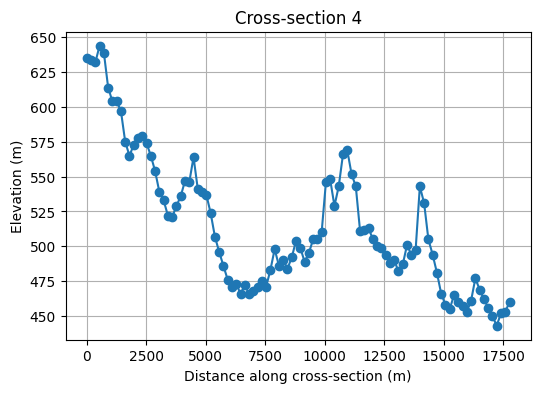

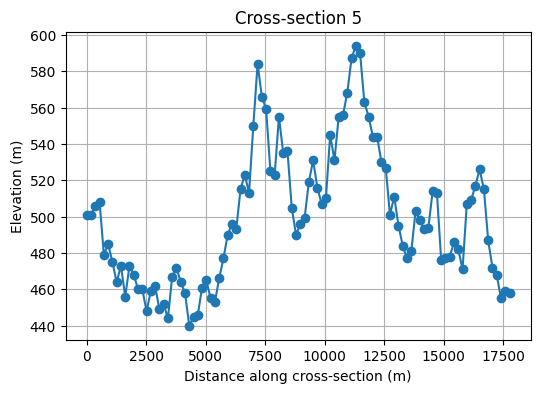

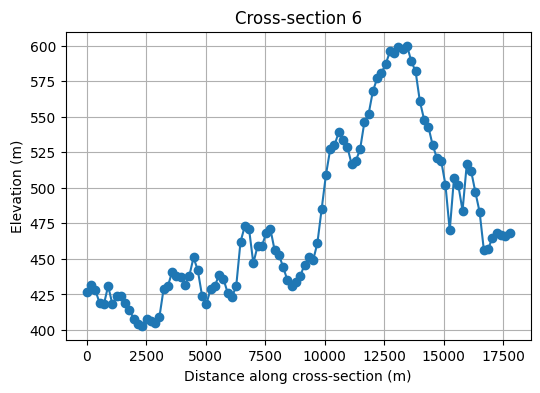

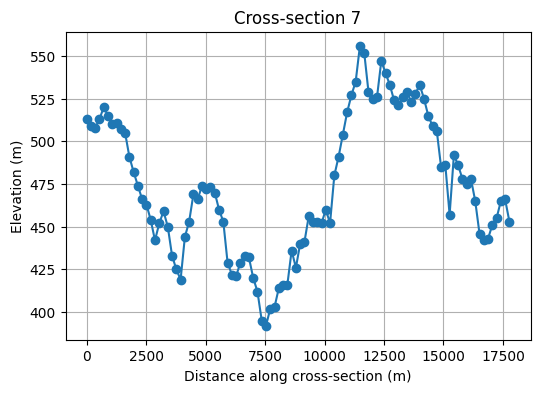

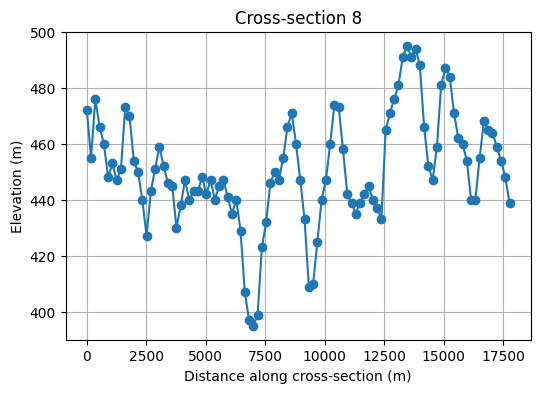

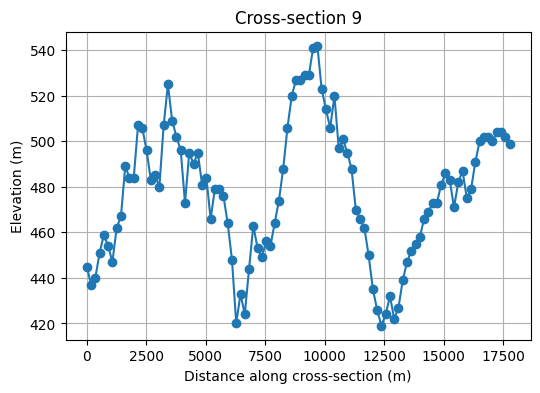

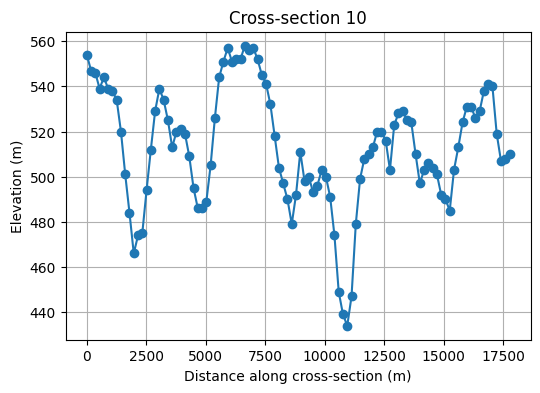

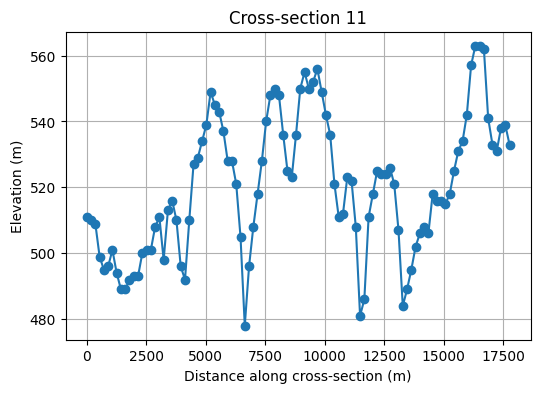

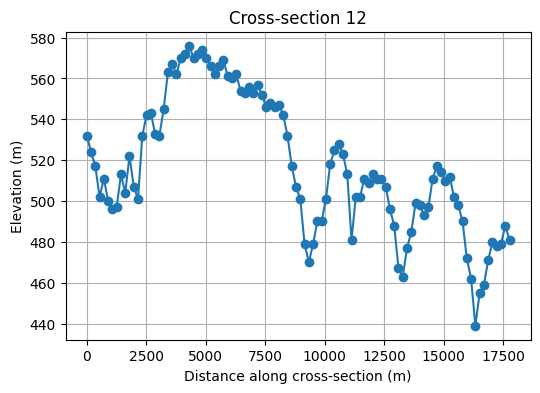

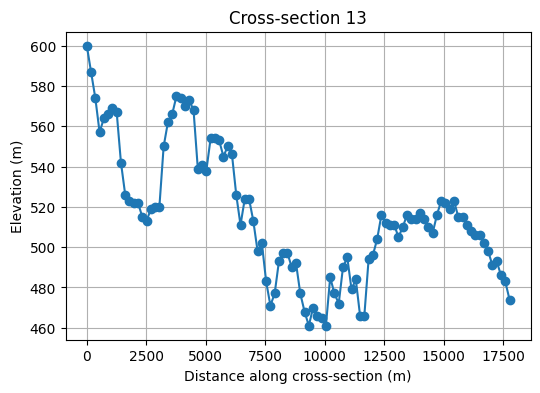

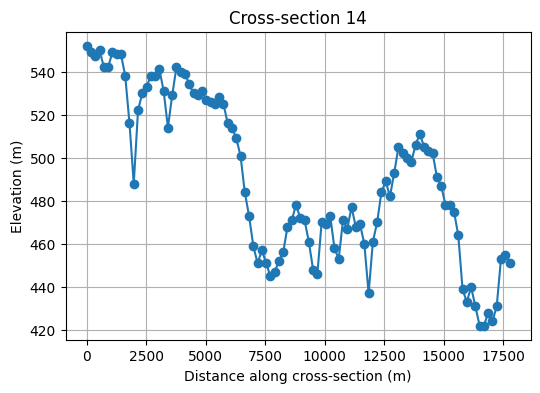

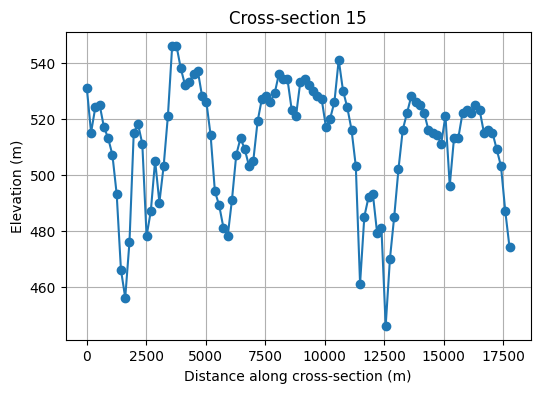

In [7]:
import matplotlib.pyplot as plt
import numpy as np

sections_metric = sections_gdf.to_crs(3857)

for i, profile in enumerate(profiles):

    length = sections_metric.geometry.iloc[i].length
    distances = np.linspace(0, length, len(profile))

    plt.figure(figsize=(6,4))
    plt.plot(distances, profile, marker='o')

    plt.title(f"Cross-section {i+1}")
    plt.xlabel("Distance along cross-section (m)")
    plt.ylabel("Elevation (m)")
    plt.grid(True)

    plt.show()


## Preparing Cross-Section Statistics for Spatial Export

This section organizes elevation profile results into structured lists that will later be used to create a spatial dataset summarizing terrain characteristics along each cross-section.

### Workflow Description

1. **Initialization of Storage Containers**

   * Creates empty lists to store:

     * Cross-section geometries
     * Profile identifiers
     * Summary elevation statistics (mean, minimum, maximum)

2. **Cross-Section Iteration**

   * Loops through each generated cross-section geometry.
   * Associates each section with its corresponding elevation profile.

3. **Geometry Assignment**

   * Stores the section line geometry itself as the spatial representation of the profile.

4. **Profile Identification**

   * Assigns a unique ID to each cross-section for tracking and referencing.

5. **Statistical Computation**

   * Calculates summary statistics from sampled elevation values:

     * **Mean elevation** — overall terrain level along the section
     * **Minimum elevation** — lowest sampled point
     * **Maximum elevation** — highest sampled point

### Purpose

This step prepares the data for geospatial analysis or export by converting raw elevation samples into meaningful descriptive metrics. These statistics can support:

* Terrain comparison across transects
* Environmental or infrastructure planning
* Spatial visualization and mapping
* GIS-based reporting or shapefile creation


In [8]:
from shapely.geometry import LineString
import geopandas as gpd
import numpy as np

profile_geoms = []
profile_ids = []
mean_elev = []
min_elev = []
max_elev = []

for i, sec in enumerate(sections_gdf.geometry):

    profile_geoms.append(sec)        # use section line itself
    profile_ids.append(i + 1)

    elev = profiles[i]               # elevation list for this section
    mean_elev.append(np.mean(elev))
    min_elev.append(np.min(elev))
    max_elev.append(np.max(elev))


## Creating a GeoDataFrame of Cross-Section Elevation Statistics

This section converts the computed elevation statistics and corresponding cross-section geometries into a structured GeoDataFrame for spatial analysis and export.

### Workflow Description

1. **Attribute Assembly**

   * Combines previously calculated data into a tabular structure:

     * `profile_id` — unique identifier for each cross-section
     * `mean_elev` — average elevation along the section
     * `min_elev` — lowest sampled elevation
     * `max_elev` — highest sampled elevation

2. **Geometry Integration**

   * Attaches the cross-section line geometries to the dataset.
   * Ensures each statistical record is spatially represented.

3. **Coordinate Reference System**

   * Applies the same CRS as the original cross-sections.
   * Maintains spatial consistency for mapping and GIS operations.

### Purpose

Constructing a GeoDataFrame enables the elevation statistics to be:

* Visualized directly on maps
* Exported to GIS formats (e.g., Shapefile, GeoJSON)
* Used in spatial analysis workflows
* Integrated into reporting or modeling pipelines

This step transforms numerical profile summaries into a fully spatial dataset ready for geospatial use.


In [9]:
profiles_gdf = gpd.GeoDataFrame(
    {
        "profile_id": profile_ids,
        "mean_elev": mean_elev,
        "min_elev": min_elev,
        "max_elev": max_elev
    },
    geometry=profile_geoms,
    crs=sections_gdf.crs
)


## Export

## Exporting Cross-Section Elevation Profiles to Shapefile

This section saves the spatial dataset of cross-section elevation statistics to a Shapefile for use in external GIS software.

### Workflow Description

1. **File Export**

   * Writes the `profiles_gdf` GeoDataFrame to disk using `GeoPandas.to_file()`.
   * Stores both geometry and attribute data in ESRI Shapefile format.

2. **Output Contents**
   The exported dataset includes:

   * Cross-section line geometries
   * Profile identifiers
   * Mean elevation values
   * Minimum elevation values
   * Maximum elevation values

3. **Destination**

   * The file is saved to a specified directory for access in tools such as:

     * ArcGIS
     * QGIS
     * Other GIS or spatial analysis platforms

### Purpose

Exporting the data allows the results of the elevation analysis to be shared, visualized, or further processed outside the Python environment. This supports:

* Professional GIS mapping workflows
* Reporting and documentation
* Integration into engineering or environmental studies
* Long-term data storage and reproducibility


In [10]:
profiles_gdf.to_file(
    r"C:/Users/HP/Documents/Arc files/elevationn_profiles.shp"
)


## Exporting Raw Elevation Profiles to CSV

This section converts the raw elevation data along each cross-section into a tabular CSV format for further analysis or record-keeping.

### Workflow Description

1. **DataFrame Creation**

   * Converts the list of elevation profiles (`profiles`) into a `pandas.DataFrame`.
   * Each row represents one cross-section.
   * Each column represents a sampled point along the section.

2. **Profile Identification**

   * Adds a `section_id` column to uniquely identify each cross-section.
   * Ensures traceability between the CSV and the corresponding spatial data.

3. **CSV Export**

   * Saves the DataFrame to disk as a CSV file using `to_csv()`.
   * Does not include the DataFrame index to keep the file clean.

4. **Confirmation**

   * Prints the file path to indicate successful export.

### Purpose

Exporting the raw elevation profiles in CSV format allows:

* Easy inspection and analysis in spreadsheet software (Excel, Google Sheets)
* Input for statistical analysis, machine learning, or modeling
* Preservation of original sampled elevation data
* Sharing with collaborators who do not use GIS software


In [11]:
import pandas as pd

# Convert elevation lists to table
profiles_df = pd.DataFrame(profiles)

# Add profile id column
profiles_df.insert(0, 'section_id', range(1, len(profiles_df)+1))

# Save CSV
profiles_df.to_csv("C:/Users/HP/Documents/Arc files/cross_section_profilesss.csv", index=False)

print("C:/Users/HP/Documents/Arc files/cross_section_profilesss.csv")


C:/Users/HP/Documents/Arc files/cross_section_profilesss.csv


# Geemap

## Visualizing Global DEM Using Google Earth Engine and geemap

This section sets up an interactive map to visualize Digital Elevation Model (DEM) data from Google Earth Engine (GEE) using `geemap`.

### Workflow Description

1. **Library Imports**

   * `ee` — Google Earth Engine Python API
   * `geemap` — interactive mapping and visualization in Python
   * `numpy`, `pandas`, `geopandas`, `shapely` — for numerical and spatial operations

2. **Google Earth Engine Initialization**

   * Authenticates and initializes the GEE session with:

     ```python
     ee.Authenticate()
     ee.Initialize()
     ```
   * Ensures access to Earth Engine datasets and services.

3. **Map Creation**

   * Creates an interactive map centered at `(6.5, 3.6)` (approx. Lekki, Nigeria) with zoom level 10.
   * `geemap.Map()` enables zooming, panning, and layer control.

4. **DEM Loading**

   * Loads the SRTM DEM dataset: `"USGS/SRTMGL1_003"`.
   * Sets visualization parameters:

     * `min` / `max` → elevation range (0–4000 m)
     * `palette` → color scheme (`terrain`)

5. **Map Layer Addition**

   * Adds the DEM to the interactive map.
   * Enables `layer_manager` for toggling layers and managing map display.

6. **Display**

   * Displays the map `m` in the notebook for interactive exploration.

### Purpose

This setup allows:

* Quick inspection of terrain in the area of interest
* Interactive exploration of elevation variations
* Preparation for downstream geospatial analysis and cross-section extraction
* Integration of Earth Engine datasets with local GIS workflows


In [34]:
import ee
import geemap
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import LineString
from shapely.affinity import rotate
import ee

ee.Authenticate()
ee.Initialize()


#important
m = geemap.Map(center=(6.5, 3.6), zoom=10)
dem = ee.Image("USGS/SRTMGL1_003")
vis_params = {
    "min": 0,
    "max": 4000,
    "palette": "terrain",
}
m.add_layer(dem, vis_params, "SRTM DEM")
m.add("layer_manager")
m

Map(center=[6.5, 3.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

## Selecting User-Defined Features and Clipping DEM in Google Earth Engine

This section uses features drawn by the user on the interactive map to define analysis inputs and clips the DEM to a region of interest (ROI).

### Workflow Description

1. **Retrieve User-Drawn Features**

   * `m.user_rois` contains all line features drawn on the map.
   * `fc.toList(fc.size())` converts the feature collection to a list for indexed access.

2. **Assign Features**

   * `line` → first feature, representing the base cross-section line.
   * `path` → second feature, representing the path along which cross-sections will be generated.
   * `roi` → polygon drawn by the user for clipping the DEM to a study area.

3. **Load and Clip DEM**

   * Loads the SRTM DEM (`USGS/SRTMGL1_003`).
   * Clips the DEM to the user-defined `roi` polygon to limit the analysis to the area of interest, improving performance and visualization clarity.

### Purpose

Clipping the DEM ensures that:

* Only the relevant portion of terrain is analyzed
* Data processing is more efficient
* Visualization is focused on the study area
* Downstream operations, such as cross-section generation and elevation extraction, are spatially constrained


In [35]:
fc = m.user_rois
features = fc.toList(fc.size())

line = ee.Feature(features.get(0))  # base line
path = ee.Feature(features.get(1))  # path along which cross sections are generated
roi = m.user_roi                   # polygon for clipping DEM

# ---- Step 2: Load DEM and clip ----
dem = ee.Image("USGS/SRTMGL1_003")  # or any DEM
clipped_dem = dem.clip(roi)

In [38]:
# m.addLayer(line, {"color":"red"}, "Line")
# m.addLayer(path, {"color":"blue"}, "Path")
# m

## Generating and Sampling Perpendicular Cross-Sections from Path in Google Earth Engine

This section generates perpendicular cross-section lines along a user-defined path, samples elevation values from the clipped DEM, and exports the results as a spatial dataset.

### Workflow Description

1. **Convert EE Geometries to GeoDataFrames**

   * Retrieves coordinates from the Earth Engine `line` and `path` features using `.getInfo()`.
   * Converts them into `GeoDataFrame` objects for local processing in Python.
   * Projects geometries to a metric CRS (EPSG:3857) for distance-based calculations.

2. **Define Cross-Section Parameters**

   * `section_length` → total length of each cross-section (from base line).
   * `half_len` → half the section length for centering.
   * `interval` → spacing between cross-sections along the path (200 m in this example).

3. **Generate Perpendicular Cross-Sections**

   * Interpolates points along the path at each interval.
   * Computes local path direction using a small forward step.
   * Rotates a base horizontal line 90° to create perpendicular sections.
   * Translates each section to the interpolated path point.
   * Stores all cross-sections in a GeoDataFrame.

4. **Sample Elevation Along Each Section**

   * Defines a function `sample_dem_along_line()` to sample elevation values at evenly spaced points along a line.
   * Iterates over all cross-sections, sampling elevations from the clipped DEM.
   * Adds the elevation lists as a new column in the `sections_gdf` GeoDataFrame.

5. **Export Results**

   * Saves the cross-sections along with their sampled elevations to a shapefile: `"cross_sections_with_elevation.shp"`.
   * Each row represents a cross-section with its associated elevation profile.

6. **Optional Visualization**

   * Plots all cross-section lines for a quick spatial check.

### Purpose

This step enables:

* Systematic terrain profiling along a path
* Integration of elevation data with GIS workflows
* Export for downstream analysis or mapping
* Efficient sampling from Earth Engine DEMs while maintaining spatial reference

The resulting dataset can be used for:

* Hydrological or coastal studies
* Infrastructure planning
* Environmental monitoring
* Visualization and reporting


Generated 22 cross sections
Saved cross-sections with elevations to shapefile.


<Axes: >

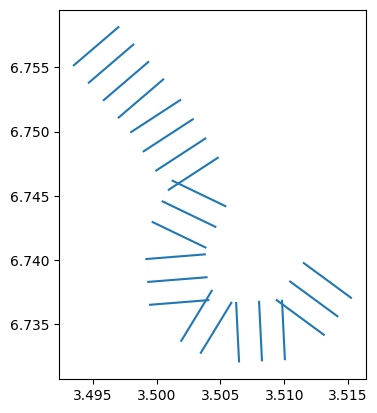

In [36]:
line_coords = line.geometry().coordinates().getInfo()
path_coords = path.geometry().coordinates().getInfo()

line_gdff = gpd.GeoDataFrame(geometry=[LineString(line_coords)], crs="EPSG:4326")
path_gdff = gpd.GeoDataFrame(geometry=[LineString(path_coords)], crs="EPSG:4326")

# Project to metric CRS for distance calculations
line_proj = line_gdff.to_crs(epsg=3857)
path_proj = path_gdff.to_crs(epsg=3857)

line_geom = line_proj.geometry.iloc[0]
path_geom = path_proj.geometry.iloc[0]

# ---- Step 5: Generate perpendicular cross-sections ----
section_length = line_geom.length
half_len = section_length / 2
interval = 200  # meters between sections

distances = np.arange(0, path_geom.length, interval)
sections = []

for d in distances:
    # Point on path
    p = path_geom.interpolate(d)
    # Small step forward for direction
    p2 = path_geom.interpolate(min(d + 1, path_geom.length))
    dx = p2.x - p.x
    dy = p2.y - p.y
    angle = np.degrees(np.arctan2(dy, dx))
    
    # Base horizontal line centered at origin
    temp_line = LineString([(-half_len, 0), (half_len, 0)])
    
    # Rotate to perpendicular
    perp_line = rotate(temp_line, angle + 90, origin=(0,0))
    
    # Translate to point location
    perp_line = LineString([(cx + p.x, cy + p.y) for cx, cy in perp_line.coords])
    sections.append(perp_line)

sections_gdf = gpd.GeoDataFrame(geometry=sections, crs=3857)
sections_gdf = sections_gdf.to_crs(epsg=4326)
print("Generated", len(sections_gdf), "cross sections")

# ---- Step 6: Sample elevations along cross-sections ----
def sample_dem_along_line(elevation_image, line_geom, n_points=25):
    xs = np.linspace(line_geom.coords[0][0], line_geom.coords[-1][0], n_points)
    ys = np.linspace(line_geom.coords[0][1], line_geom.coords[-1][1], n_points)
    elevs = []
    for x, y in zip(xs, ys):
        # Sample elevation from Earth Engine DEM
        elev = elevation_image.sample(ee.Geometry.Point([x, y])).first().get('elevation').getInfo()
        elevs.append(elev)
    return elevs

# Sample each cross-section and store elevations
elevations_list = []
for sec in sections_gdf.geometry:
    elev_profile = sample_dem_along_line(clipped_dem, sec, n_points=25)
    elevations_list.append(elev_profile)

# Attach sampled elevations to GeoDataFrame
sections_gdf['elevations'] = elevations_list  # each row has a list of elevations along the line

# ---- Step 7: Save as shapefile ----
sections_gdf.to_file("cross_sections_with_elevation.shp")
print("Saved cross-sections with elevations to shapefile.")

# ---- Optional: Plot cross-section lines ----
sections_gdf.plot()

## Visualizing Sampled Cross-Sections in Google Earth Engine

This section displays the previously generated cross-section lines on an interactive map using `geemap` and attaches the sampled elevation data to each line as properties.

### Workflow Description

1. **Map Initialization**

   * Creates an interactive map centered on Lagos `(6.5, 3.6)` with zoom level 12.

2. **Ensure Consistent CRS**

   * Converts `sections_gdf` to geographic coordinates (EPSG:4326) for compatibility with Earth Engine.

3. **Convert GeoDataFrame to EE Features**

   * Iterates over each row in the GeoDataFrame.
   * Converts Shapely line coordinates to EE `LineString` geometry.
   * Attaches the elevation profile for each section as a property.
   * Stores each as an `ee.Feature`.

4. **Create FeatureCollection**

   * Combines all EE features into a single `ee.FeatureCollection`.

5. **Styling for Visualization**

   * Styles the cross-section lines for display (red color, 3-pixel width).

6. **Add Layers to Map**

   * Adds the styled cross-section FeatureCollection to the map.
   * Optionally, the clipped DEM can also be added for reference.

7. **Display**

   * Shows the interactive map in the notebook for spatial exploration of cross-sections and terrain.

### Purpose

This visualization allows:

* Interactive inspection of cross-section locations
* Quick verification of spatial alignment with DEM
* Exploration of elevation data along each transect
* Integration with downstream GIS workflows or reporting
* Clear communication of analysis results in a visual format


In [38]:
m = geemap.Map(center=(6.5, 3.6), zoom=12)  # center on Lagos as example

# Ensure sections_gdf is in EPSG:4326
sections_gdf = sections_gdf.to_crs(epsg=4326)

# Convert GeoDataFrame lines to EE Features
ee_features = []
for _, row in sections_gdf.iterrows():
    coords = [[x, y] for x, y in row.geometry.coords]  # Convert shapely coords to [lon, lat]
    ee_geom = ee.Geometry.LineString(coords)
    feature = ee.Feature(ee_geom, {'elevations': row['elevations']})
    ee_features.append(feature)

# Make FeatureCollection
sections_fc = ee.FeatureCollection(ee_features)

# Style the lines (red color, 3 px width)
styled_fc = sections_fc.style(color='red', width=3)

# Add to the map
m.addLayer(styled_fc, {}, "Cross-section Lines")

# Optional: add DEM for reference
# vis_params = {'min': 0, 'max': 300, 'palette': ['blue', 'green', 'brown', 'white']}
# m.addLayer(clipped_dem, vis_params, "Clipped DEM")

m


Map(center=[6.5, 3.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', tr…

## Plotting Elevation Profiles of Cross-Sections

This section visualizes the elevation profiles sampled along each cross-section as line plots.

### Workflow Description

1. **Determine Number of Sample Points**

   * Retrieves the number of sampled points along a cross-section from the first row of `sections_gdf['elevations']`.

2. **Iterate Over Cross-Sections**

   * Loops through each row in the GeoDataFrame.
   * Extracts the elevation profile for the current cross-section.

3. **X-Axis Construction**

   * Uses `np.linspace` to create a normalized x-axis from 0 to 1 (fraction along the line).
   * Optionally, actual distances along the line can be used for a true spatial scale.

4. **Plotting**

   * Creates a new figure for each profile.
   * Plots elevation against distance along the cross-section.
   * Adds title, axis labels, and grid for readability.

5. **Display**

   * Shows each plot individually for inspection and comparison.

### Purpose

This visualization allows:

* Assessment of terrain variation along each cross-section
* Comparison between multiple cross-sections
* Identification of slopes, peaks, or depressions
* Verification of elevation sampling before further analysis or export


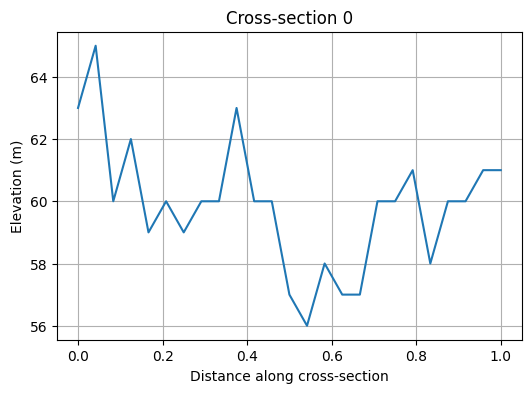

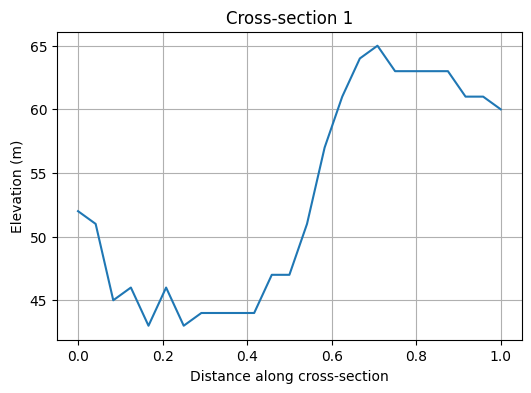

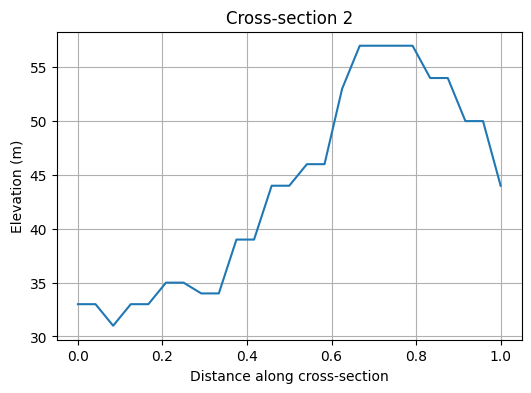

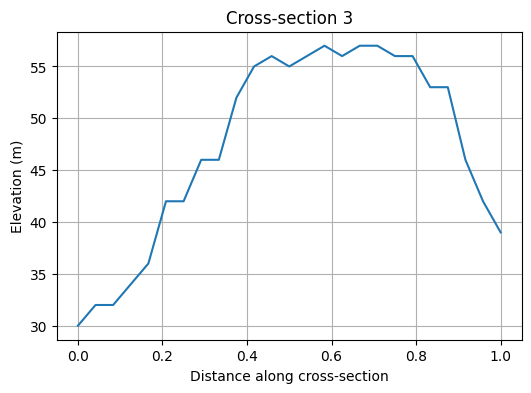

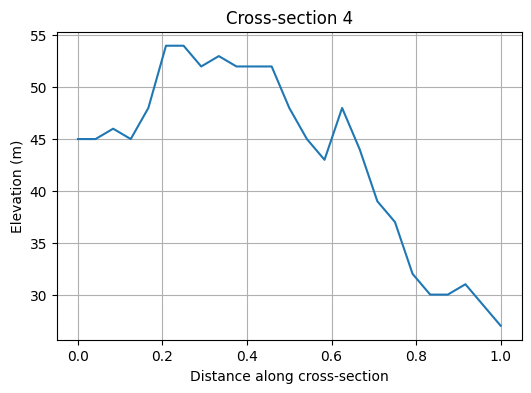

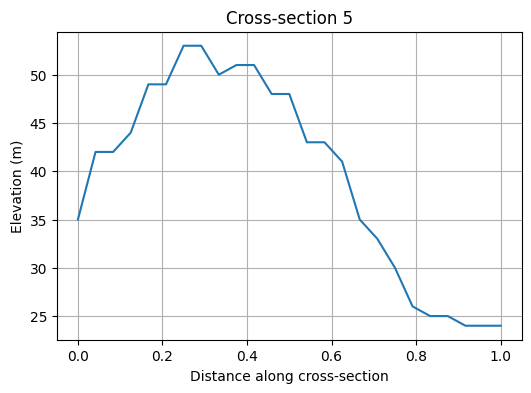

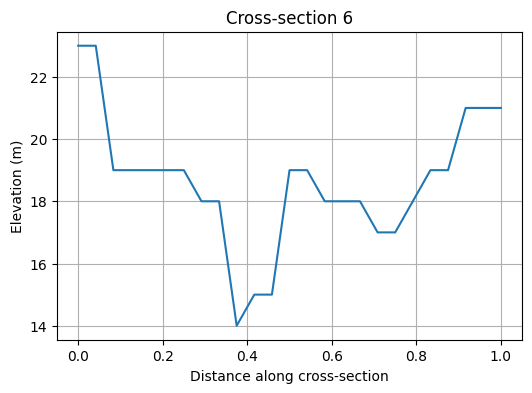

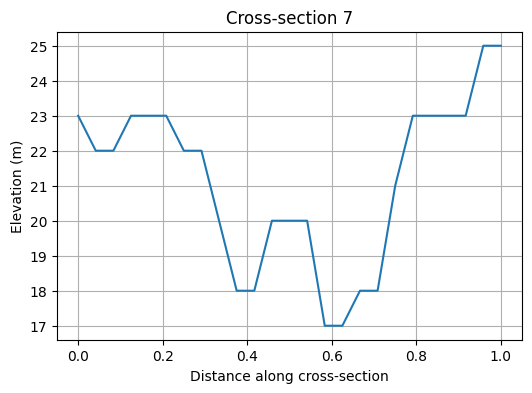

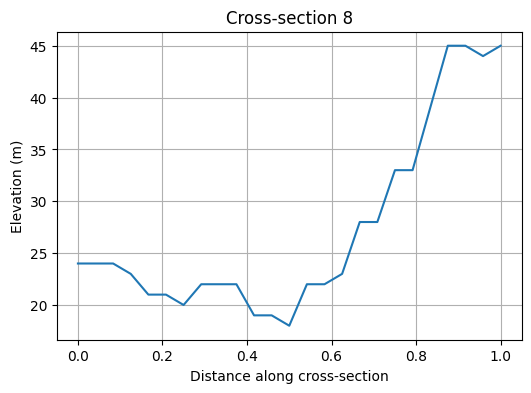

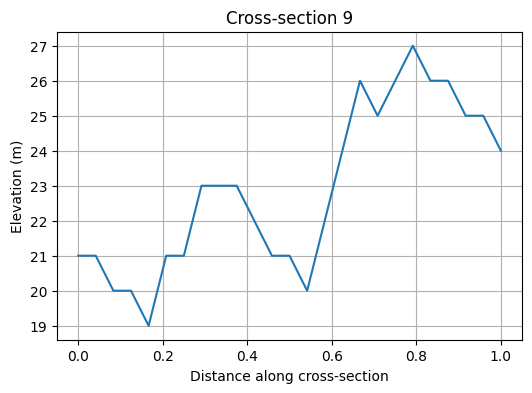

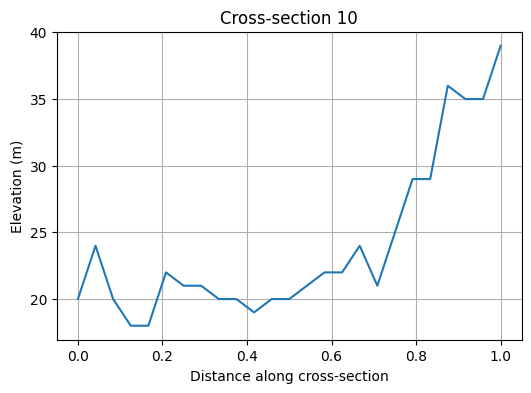

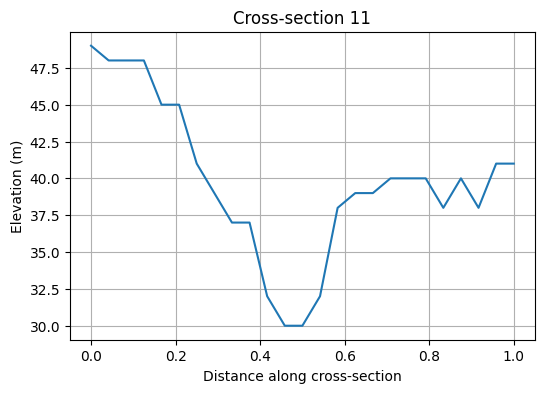

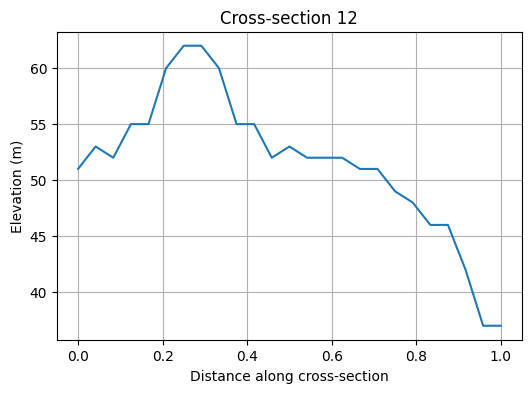

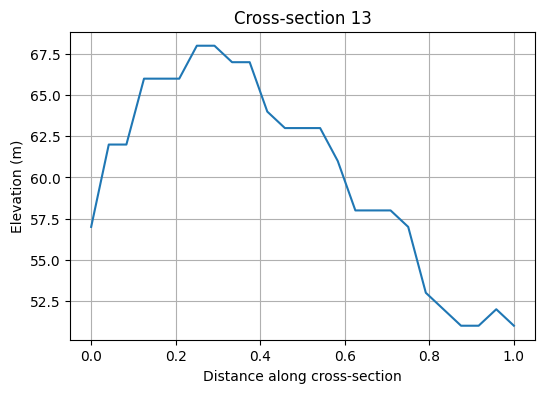

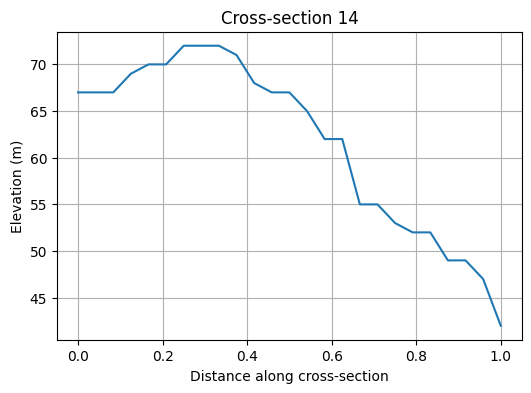

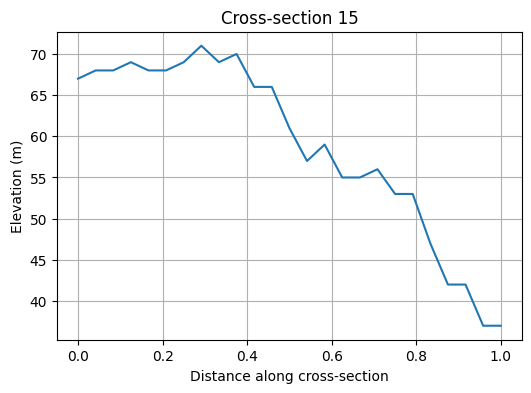

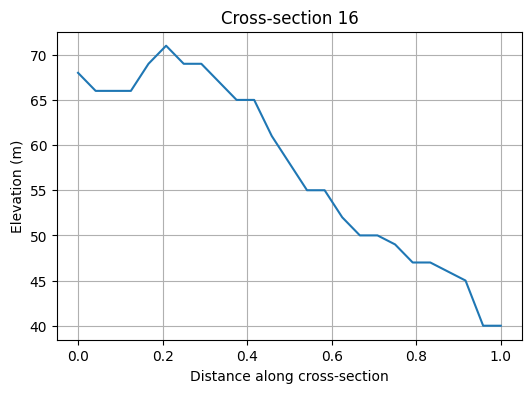

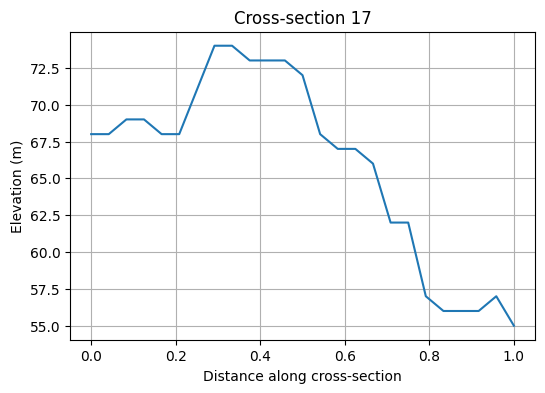

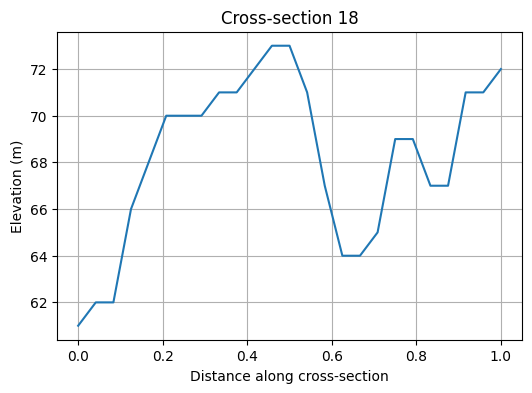

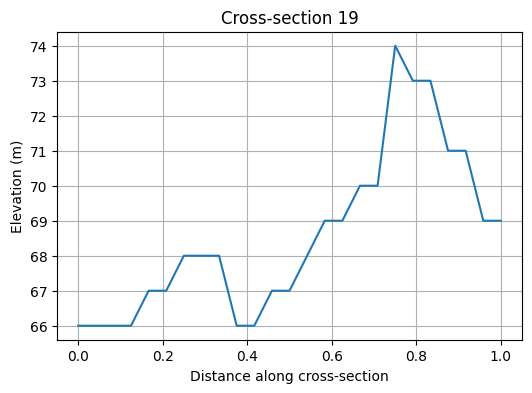

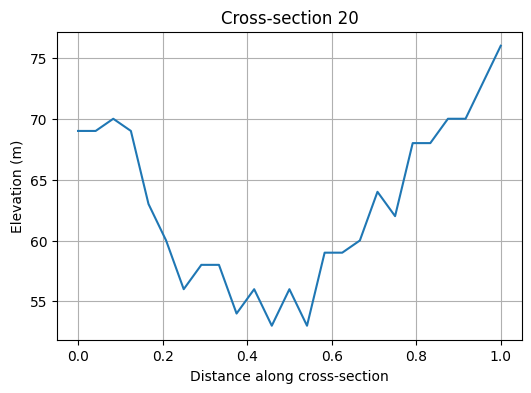

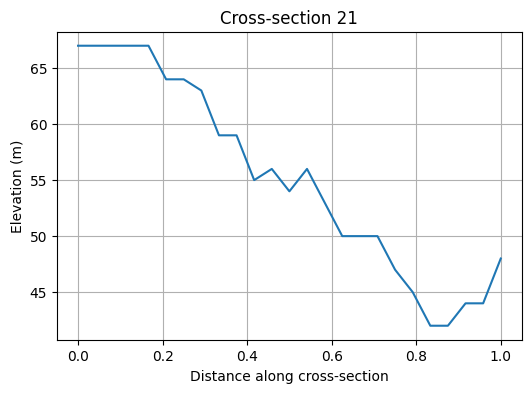

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Number of points along each cross-section (from your sampling)
n_points = len(sections_gdf['elevations'].iloc[0])

# Loop over each cross-section
for idx, row in sections_gdf.iterrows():
    elev_profile = row['elevations']
    
    # x-axis: distance along the line
    distances = np.linspace(0, 1, n_points)  # normalized 0–1 along the line
    # or use actual distance along line in meters
    # distances = np.linspace(0, row.geometry.length, n_points)
    
    plt.figure(figsize=(6,4))
    plt.plot(distances, elev_profile) #, marker='o'
    plt.title(f"Cross-section {idx}")
    plt.xlabel("Distance along cross-section")
    plt.ylabel("Elevation (m)")
    plt.grid(True)
    plt.show()


## Exporting Elevation Profiles to CSV

This section converts the sampled elevation profiles stored in the GeoDataFrame into a tabular CSV format for external analysis or record-keeping.

### Workflow Description

1. **Convert List Column to Table**

   * `sections_gdf['elevations']` contains a list of elevation values for each cross-section.
   * `pd.DataFrame(... .tolist())` expands these lists into separate columns, with one row per cross-section.

2. **Add Section Identifier**

   * Inserts a `section_id` column to uniquely identify each cross-section.
   * Ensures traceability between CSV rows and corresponding spatial features.

3. **CSV Export**

   * Saves the DataFrame as `"cross_section_profile.csv"` using `to_csv()`.
   * Excludes the DataFrame index to keep the file clean.

4. **Confirmation**

   * Prints a message indicating the location of the saved CSV file.

### Purpose

Exporting the data allows:

* Easy access and inspection in spreadsheet software (Excel, Google Sheets)
* Use in statistical analysis, modeling, or reporting
* Sharing with collaborators who may not use GIS software
* Preservation of the original sampled elevation profiles


In [56]:
import pandas as pd

# Convert list column into separate columns
profiles_df = pd.DataFrame(
    sections_gdf['elevations'].tolist()
)

# Add section id column
profiles_df.insert(0, 'section_id', sections_gdf.index)

# Save CSV
profiles_df.to_csv("cross_section_profile.csv", index=False)

print("Saved profiles to cross_section_profile.csv")


Saved profiles to cross_section_profile.csv
